In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("salary.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
df.shape

(6704, 6)

In [4]:
df.info

<bound method DataFrame.info of        Age  Gender    Education Level              Job Title  \
0     32.0    Male         Bachelor's      Software Engineer   
1     28.0  Female           Master's           Data Analyst   
2     45.0    Male                PhD         Senior Manager   
3     36.0  Female         Bachelor's        Sales Associate   
4     52.0    Male           Master's               Director   
...    ...     ...                ...                    ...   
6699  49.0  Female                PhD  Director of Marketing   
6700  32.0    Male        High School        Sales Associate   
6701  30.0  Female  Bachelor's Degree      Financial Manager   
6702  46.0    Male    Master's Degree      Marketing Manager   
6703  26.0  Female        High School        Sales Executive   

      Years of Experience    Salary  
0                     5.0   90000.0  
1                     3.0   65000.0  
2                    15.0  150000.0  
3                     7.0   60000.0  
4        

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
df.select_dtypes(include=['int64','float64']).columns

Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

In [8]:
df.select_dtypes(include=['object']).columns

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

# Fill Numerical Values (Median)

In [9]:
df["Age"].fillna(df["Age"].median(), inplace=True)


In [10]:
df["Years of Experience"].fillna(df["Years of Experience"].median(), inplace=True)


In [11]:
df["Salary"].fillna(df["Salary"].median(), inplace=True)

In [12]:
df.isnull().sum()

Age                    0
Gender                 2
Education Level        3
Job Title              2
Years of Experience    0
Salary                 0
dtype: int64

# Fill Categorical Values (Mode)

In [13]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)


In [14]:
df["Education Level"].fillna(df["Education Level"].mode()[0], inplace=True)


In [15]:
df["Job Title"].fillna(df["Job Title"].mode()[0], inplace=True)

In [16]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

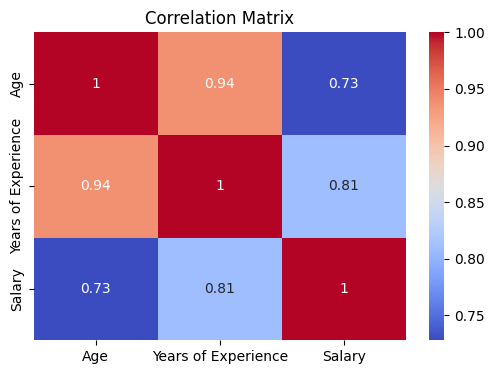

In [17]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Age","Years of Experience","Salary"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

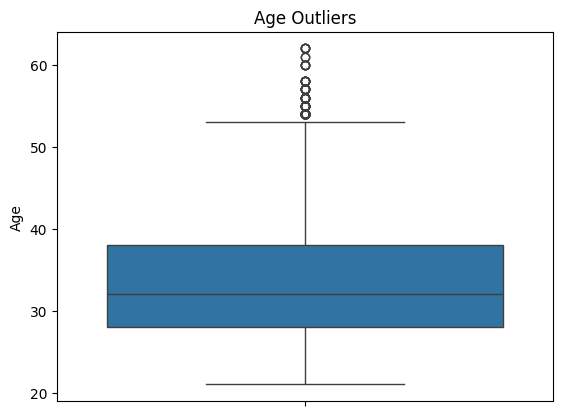

In [18]:
sns.boxplot(df["Age"])
plt.title("Age Outliers")
plt.show()

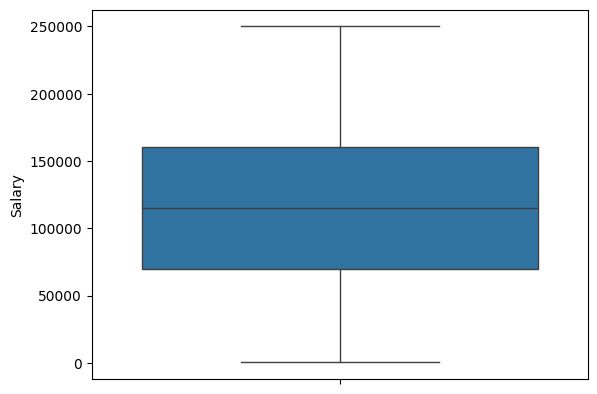

In [19]:
sns.boxplot(df["Salary"])
plt.show()

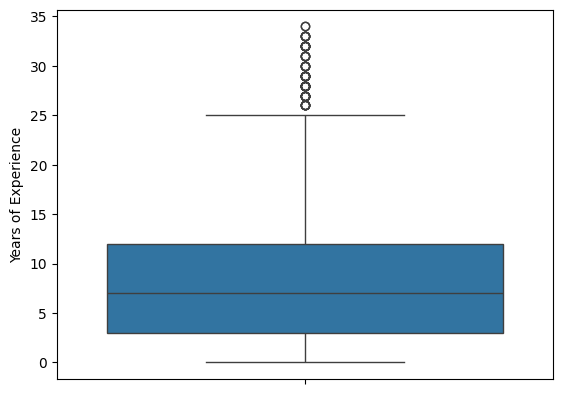

In [20]:
sns.boxplot(df["Years of Experience"])
plt.show()

In [21]:
cols = ["Age","Years of Experience","Salary"]
for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print(df.shape)

(6556, 6)


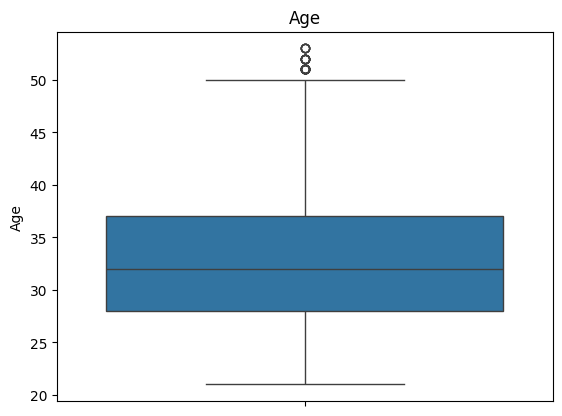

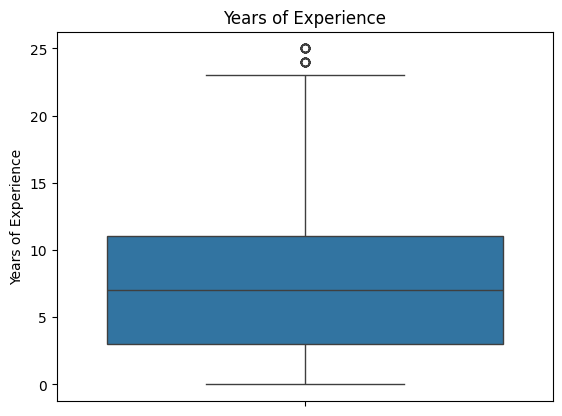

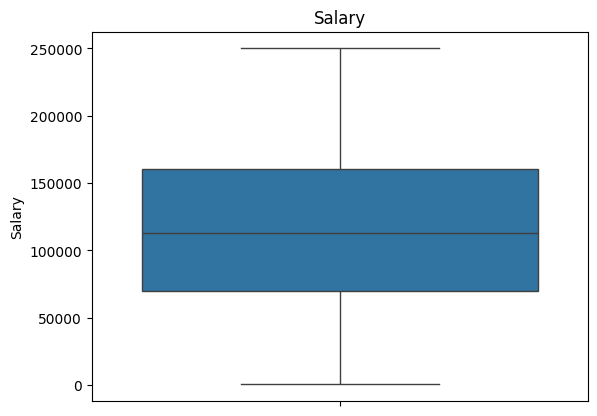

In [22]:
for col in cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [23]:
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Education Level"] = le.fit_transform(df["Education Level"])

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [25]:
df = pd.get_dummies(df, columns=["Job Title"], drop_first=True)

In [26]:
df.head()

,Age,Gender,Education Level,Years of Experience,Salary,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Back end Developer,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,1.0,0,5.0,90000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,0.0,3,3.0,65000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,1.0,5,15.0,150000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36.0,0.0,0,7.0,60000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,1.0,3,20.0,200000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [27]:
X = df.drop("Salary", axis=1)

y = df["Salary"]

In [28]:
print(X.head())
print(y.head())

    Age  Gender  Education Level  Years of Experience  Job Title_Accountant  \
0  32.0     1.0                0                  5.0                 False   
1  28.0     0.0                3                  3.0                 False   
2  45.0     1.0                5                 15.0                 False   
3  36.0     0.0                0                  7.0                 False   
4  52.0     1.0                3                 20.0                 False   

   Job Title_Administrative Assistant  Job Title_Back end Developer  \
0                               False                         False   
1                               False                         False   
2                               False                         False   
3                               False                         False   
4                               False                         False   

   Job Title_Business Analyst  Job Title_Business Development Manager  \
0                       F

In [29]:
df["Gender"].dtype

dtype('float64')

In [30]:
df["Gender"].unique()

array([ 1.,  0., nan])

In [31]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

In [32]:
df.isnull().sum()

Age                           0
Gender                        0
Education Level               0
Years of Experience           0
Salary                        0
                             ..
Job Title_UX Designer         0
Job Title_UX Researcher       0
Job Title_VP of Finance       0
Job Title_VP of Operations    0
Job Title_Web Developer       0
Length: 197, dtype: int64

In [33]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

LinearRegression()

In [35]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[ 54391.3967556   68211.46025104 100547.44499178 112347.98118564
 171397.41307605]


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [37]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -3.3556420991003595e+19


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [38]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 15049381771736.707


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [39]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 8.995241280752847e+28


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [40]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 299920677525789.25


In [52]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

LinearRegression()

In [44]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

In [45]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

In [46]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_test, y_pred):

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return r2, mae, rmse

In [47]:
lin_r2, lin_mae, lin_rmse = evaluate_model(y_test, y_pred)

poly_r2, poly_mae, poly_rmse = evaluate_model(y_test, y_pred_poly)

ridge_r2, ridge_mae, ridge_rmse = evaluate_model(y_test, y_pred_ridge)

lasso_r2, lasso_mae, lasso_rmse = evaluate_model(y_test, y_pred_lasso)

c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a

In [48]:
import pandas as pd

results = pd.DataFrame({

    "Model": ["Linear","Polynomial","Ridge","Lasso"],

    "R2 Score":[lin_r2, poly_r2, ridge_r2, lasso_r2],

    "MAE":[lin_mae, poly_mae, ridge_mae, lasso_mae],

    "RMSE":[lin_rmse, poly_rmse, ridge_rmse, lasso_rmse]

})

print(results)

        Model      R2 Score           MAE          RMSE
0      Linear -3.355642e+19  1.504938e+13  2.999207e+14
1  Polynomial -7.963407e+12  1.005731e+10  1.461060e+11
2       Ridge  8.483021e-01  1.454503e+04  2.016547e+04
3       Lasso  8.488384e-01  1.449683e+04  2.012979e+04


In [49]:
import joblib

joblib.dump(poly_model, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']

In [50]:
joblib.dump(poly, "poly_transform.pkl")

['poly_transform.pkl']

In [51]:
import joblib

joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']